# Phase 8 — Efficient ViT / Hybrid-Attention Results Analysis

Joins Phase 8's local-attention results (`swin_pico_w2/w4/w8`, `swin_pico_poolmixer`,
`hybrid_bottleneck_swin`, `vit_tiny`, `deit_tiny`) to Phase 1-3's classification results
and tests H1-H5 from `ideas/PHASE8_PLAN.md`.

## Validity banner — read before trusting any number below

**As of this writing, only 5 of 7 Phase 8 models have results**: `swin_pico_w2/w4/w8`,
`swin_pico_poolmixer`, and `hybrid_bottleneck_swin` trained via
`python -m scripts.train --experiment phase8`. `vit_tiny`/`deit_tiny` need
`notebooks/phase_8_efficient_vit/vit_qat_phase8.ipynb`
(blocked, as of this writing, on restoring the `mobilenetv2` teacher checkpoint the
distillation stage depends on) and have not been trained yet. Every load cell below is
disk-driven (globs `outputs/pcad/phase8/*/results/*_summary.json` plus the training
notebook's own output path for vit_tiny/deit_tiny) rather than a hardcoded 7-model list,
and every hypothesis cell prints `[skip]`/`[blocked]` instead of hard-failing when a model
is missing — re-running this notebook once vit_tiny/deit_tiny land fills in H4 and the
7-model comparisons with no edits needed.

**H5's scope is narrower than `ideas/PHASE8_PLAN.md` Task 7 asks for.** `profile_kernel_trace()`
(`ml/profiling.py`) returns per-op device-time timings and a best-effort
`winograd_trace_detected` flag, but not the per-module (stem vs. attention-stage) breakdown
the plan's H5 describes — that needs new forward-hook instrumentation, out of scope for an
analysis notebook. This notebook reports whole-model latency and the per-op Winograd signal;
see Limitations at the end.


## Configuration

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "models").exists() and (candidate / "results").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))  # so `import ml`/`import models` resolve regardless of kernel cwd
print(f"Project root: {PROJECT_ROOT}")

PHASE8_CLI_DIR = PROJECT_ROOT / "outputs" / "pcad" / "phase8"
PHASE8_NOTEBOOK_RESULTS = PROJECT_ROOT / "results" / "phase_8_efficient_vit_hybrid_attention_training" / "experiment_summary.json"
PHASE8_NOTEBOOK_CKPT_DIR = PROJECT_ROOT / "checkpoints" / "phase_8_efficient_vit_hybrid_attention_training"
CROSS_PHASE_CSV = PROJECT_ROOT / "results" / "results_aggregate" / "model_details_cross_phase.csv"
RESULTS_DIR = PROJECT_ROOT / "results" / "phase_8_efficient_vit_hybrid_attention_analysis"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures_generated" / "phase_8_efficient_vit_hybrid_attention"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from ml.plotting import apply_report_style
apply_report_style()

SWIN_SWEEP_ORDER = ["swin_pico_w2", "swin_pico_w4", "swin_pico_w8"]
PHASE8_MODEL_ORDER = ["swin_pico_w2", "swin_pico_w4", "swin_pico_w8",
                      "swin_pico_poolmixer", "hybrid_bottleneck_swin",
                      "vit_tiny", "deit_tiny"]
PHASE8_COLORS = {
    "swin_pico_w2": "#8ecae6", "swin_pico_w4": "#4a9fd4", "swin_pico_w8": "#1b6ca8",
    "swin_pico_poolmixer": "#9c89b8", "hybrid_bottleneck_swin": "#eb6834",
    "vit_tiny": "#2a9d8f", "deit_tiny": "#e76f51",
}
CNN_COLOR = "#6c757d"


Project root: /home/rafael/Documents/alexnet_rafael


/home/rafael/Documents/alexnet_rafael/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Phase 8 Results

CLI-trained models (`swin_pico_*`, `hybrid_bottleneck_swin`) each write
`outputs/pcad/phase8/{model}/results/{model}_summary.json` (`ml/reporting.py`'s
`make_run_summary()` schema — one flat dict per model, same shape every prior phase uses).
`vit_tiny`/`deit_tiny` come from the training notebook's `create_results_summary()` output
instead (`results/phase_8_efficient_vit_hybrid_attention_training/experiment_summary.json`),
a *nested* `{"fp32_metrics": {...}, "int8_metrics": {...}, ...}` shape — flattened into the
same per-model row schema here so both sources merge into one DataFrame.

In [2]:
def load_cli_summaries(cli_dir: Path) -> list[dict]:
    rows = []
    for summary_path in sorted(cli_dir.glob("*/results/*_summary.json")):
        rows.append(json.loads(summary_path.read_text()))
    return rows


def load_notebook_summary(summary_path: Path, ckpt_dir: Path) -> list[dict]:
    """Flatten vit_qat_phase8.ipynb's experiment_summary.json (Section 10) into
    per-model rows matching ml.reporting.make_run_summary()'s flat schema. Falls back to
    per-model params/size from disk (checkpoint sizes, param count) so this stays usable
    even if a field the CLI schema has isn't present in the notebook's summary.
    """
    if not summary_path.exists():
        return []
    raw = json.loads(summary_path.read_text())
    fp32_metrics = raw.get("fp32_metrics", {})
    int8_metrics = raw.get("int8_metrics", {})
    fp32_training = raw.get("fp32_training_results", {})

    rows = []
    for name in ("vit_tiny", "deit_tiny"):
        if name not in fp32_metrics or name not in int8_metrics:
            continue
        fp32_best = ckpt_dir / f"{name}_best.pth"
        int8_best = ckpt_dir / f"{name}.pth"
        fp32_size_mb = fp32_best.stat().st_size / 1e6 if fp32_best.exists() else None
        int8_size_mb = int8_best.stat().st_size / 1e6 if int8_best.exists() else None
        rows.append({
            "model_name": name,
            "fp32_top1": fp32_metrics[name].get("top1"),
            "fp32_top5": fp32_metrics[name].get("top5"),
            "fp32_loss": fp32_metrics[name].get("loss"),
            "int8_top1": int8_metrics[name].get("top1"),
            "int8_top5": int8_metrics[name].get("top5"),
            "int8_loss": int8_metrics[name].get("loss"),
            "quantization_drop_top1": fp32_metrics[name].get("top1", np.nan) - int8_metrics[name].get("top1", np.nan),
            "fp32_size_mb": fp32_size_mb,
            "int8_size_mb": int8_size_mb,
            "best_val_top1": fp32_training.get(name, {}).get("best_val_accuracy"),
            "epochs": len(fp32_training.get(name, {}).get("history", {}).get("train_loss", [])) or None,
        })
    return rows


rows = load_cli_summaries(PHASE8_CLI_DIR) + load_notebook_summary(PHASE8_NOTEBOOK_RESULTS, PHASE8_NOTEBOOK_CKPT_DIR)
phase8_df = pd.DataFrame(rows)

if phase8_df.empty:
    print("[skip] No Phase 8 results found on disk yet.")
else:
    phase8_df = phase8_df.set_index("model_name")
    present = [m for m in PHASE8_MODEL_ORDER if m in phase8_df.index]
    missing = [m for m in PHASE8_MODEL_ORDER if m not in phase8_df.index]
    print(f"Present ({len(present)}/7): {present}")
    if missing:
        print(f"Missing ({len(missing)}/7): {missing} -- not trained yet, see validity banner above.")


Present (5/7): ['swin_pico_w2', 'swin_pico_w4', 'swin_pico_w8', 'swin_pico_poolmixer', 'hybrid_bottleneck_swin']
Missing (2/7): ['vit_tiny', 'deit_tiny'] -- not trained yet, see validity banner above.


### Run Inventory

In [3]:
if phase8_df.empty:
    print("[skip] Nothing to show.")
else:
    display_cols = [c for c in ["fp32_top1", "int8_top1", "quantization_drop_top1",
                                 "params_m", "fp32_size_mb", "int8_size_mb", "epochs"]
                     if c in phase8_df.columns]
    print(phase8_df.loc[[m for m in PHASE8_MODEL_ORDER if m in phase8_df.index], display_cols].to_string())


                        fp32_top1  int8_top1  quantization_drop_top1  params_m  fp32_size_mb  int8_size_mb  epochs
model_name                                                                                                        
swin_pico_w2            30.641368  33.253288               -2.611920  0.321188      3.755274      0.668609      99
swin_pico_w4            31.268662  33.885661               -2.616999  0.321668      3.768091      0.677764      99
swin_pico_w8            33.030838  36.991832               -3.960994  0.323780      3.909449      0.803069      99
swin_pico_poolmixer     28.211576  30.759650               -2.548075  0.227768      2.662607      0.304627      99
hybrid_bottleneck_swin  33.638141  40.177366               -6.539226  0.267824      3.137369      0.541750      99


## Load Phase 1-3 CNN Comparison Data

`alexnet_bottleneck`/`alexnet_fire` are Phase 3's compensation Pareto-optimal picks
(`ideas/BEST_MODELS.md`); `vgg_style` is the closest FP32-size match to `vit_tiny` in the
whole project (medium-priority improvement #6, `ideas/PHASE8_PLAN.md`) and the strongest
pure-CNN baseline, not just the smallest one; `alexnet_tv` is the large-kernel reference
every kernel-restriction phase normalizes against.

In [4]:
CNN_REFERENCE_MODELS = ["alexnet_bottleneck", "alexnet_fire", "alexnet_depthwisesep", "vgg_style", "alexnet_tv"]

if CROSS_PHASE_CSV.exists():
    cross_df = pd.read_csv(CROSS_PHASE_CSV)
    name_col = "model_name" if "model_name" in cross_df.columns else "model"
    cnn_df = cross_df[cross_df[name_col].isin(CNN_REFERENCE_MODELS)].copy()
    # some models recur across phases (e.g. alexnet_tv in Phase 1 + Phase 2) -- keep the
    # earliest/canonical phase row so later merges stay one-to-one, same convention as
    # notebooks/phase_7_detection_segmentation_analysis/phase7_results_analysis.ipynb
    cnn_df = cnn_df.sort_values("phase").drop_duplicates(subset=name_col, keep="first").set_index(name_col)
    print(f"CNN reference models loaded: {list(cnn_df.index)}")
else:
    print(f"[skip] {CROSS_PHASE_CSV} not found")
    cnn_df = pd.DataFrame()


CNN reference models loaded: ['alexnet_tv', 'vgg_style', 'alexnet_bottleneck', 'alexnet_depthwisesep', 'alexnet_fire']


## H1 — Local-Attention Window Size Is the Conv-Kernel-Size Analogue

**Claim** (`ideas/PHASE8_PLAN.md`): FP32 top-1 increases monotonically with `window_size`
in `{2, 4, 8}`, reproducing Phase 2's kernel-restriction curve in attention terms.

              fp32_top1  int8_top1  window_size
model_name                                     
swin_pico_w2  30.641368  33.253288            2
swin_pico_w4  31.268662  33.885661            4
swin_pico_w8  33.030838  36.991832            8

FP32 monotonic in window_size: True
INT8 monotonic in window_size: True


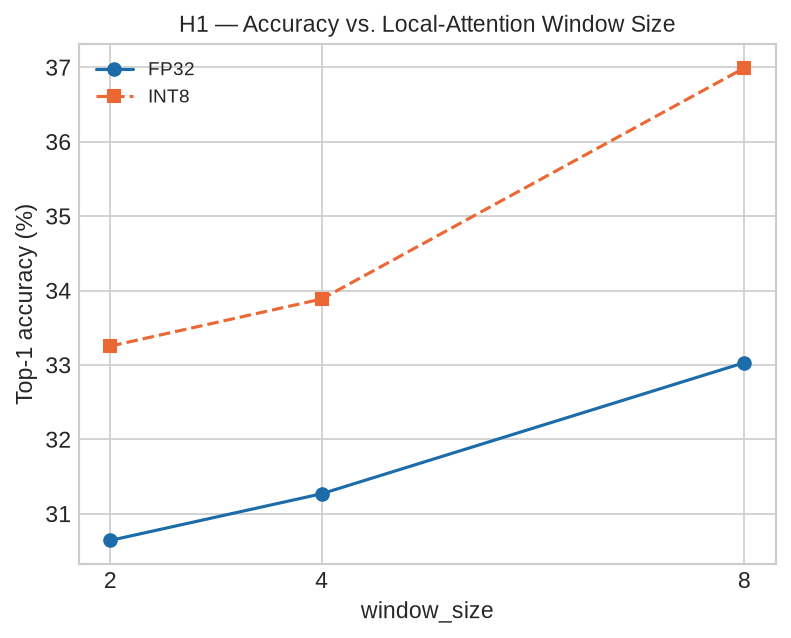

In [5]:
h1_models = [m for m in SWIN_SWEEP_ORDER if m in phase8_df.index]

if len(h1_models) < 2:
    print(f"[skip] Need at least 2 of {SWIN_SWEEP_ORDER}, have {h1_models}.")
else:
    window_sizes = {"swin_pico_w2": 2, "swin_pico_w4": 4, "swin_pico_w8": 8}
    h1_df = phase8_df.loc[h1_models, ["fp32_top1", "int8_top1"]].copy()
    h1_df["window_size"] = [window_sizes[m] for m in h1_df.index]
    h1_df = h1_df.sort_values("window_size")
    print(h1_df.to_string())

    is_monotonic_fp32 = h1_df["fp32_top1"].is_monotonic_increasing
    is_monotonic_int8 = h1_df["int8_top1"].is_monotonic_increasing
    print(f"\nFP32 monotonic in window_size: {is_monotonic_fp32}")
    print(f"INT8 monotonic in window_size: {is_monotonic_int8}")
    if len(h1_models) < 3:
        print(f"NOTE: only {len(h1_models)}/3 sweep points present -- trend is provisional.")

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(h1_df["window_size"], h1_df["fp32_top1"], "o-", label="FP32", color="#1b6ca8")
    ax.plot(h1_df["window_size"], h1_df["int8_top1"], "s--", label="INT8", color="#eb6834")
    ax.set_xlabel("window_size")
    ax.set_ylabel("Top-1 accuracy (%)")
    ax.set_xticks(h1_df["window_size"])
    ax.set_title("H1 — Accuracy vs. Local-Attention Window Size")
    ax.legend()
    fig.savefig(FIGURES_DIR / "phase8_h1_window_size_sweep.png")
    plt.show()


## H2 — CNN-Stem + Attention Hybrid vs. Pure CNN / Pure Swin

**Claim**: `hybrid_bottleneck_swin` (H2, CNN stem for local texture + Swin body for
longer-range mixing) beats both a pure-CNN compensation architecture
(`alexnet_bottleneck`/`alexnet_fire`) and a pure-Swin model (`swin_pico_w8`, the least
window-restricted sweep point) at comparable size — same accuracy-vs-size Pareto framing
`ideas/BEST_MODELS.md` already uses for Phase 3/4.

                 model    family  int8_top1  int8_size_mb
    alexnet_bottleneck       CNN  44.539082      0.431780
          alexnet_fire       CNN  44.303995      0.551374
             vgg_style       CNN  51.188743      2.376703
          swin_pico_w8 attention  36.991832      0.803069
hybrid_bottleneck_swin    hybrid  40.177366      0.541750

Hybrid vs. pure-Swin (w8): 40.18% vs. 36.99% (+3.19pp)


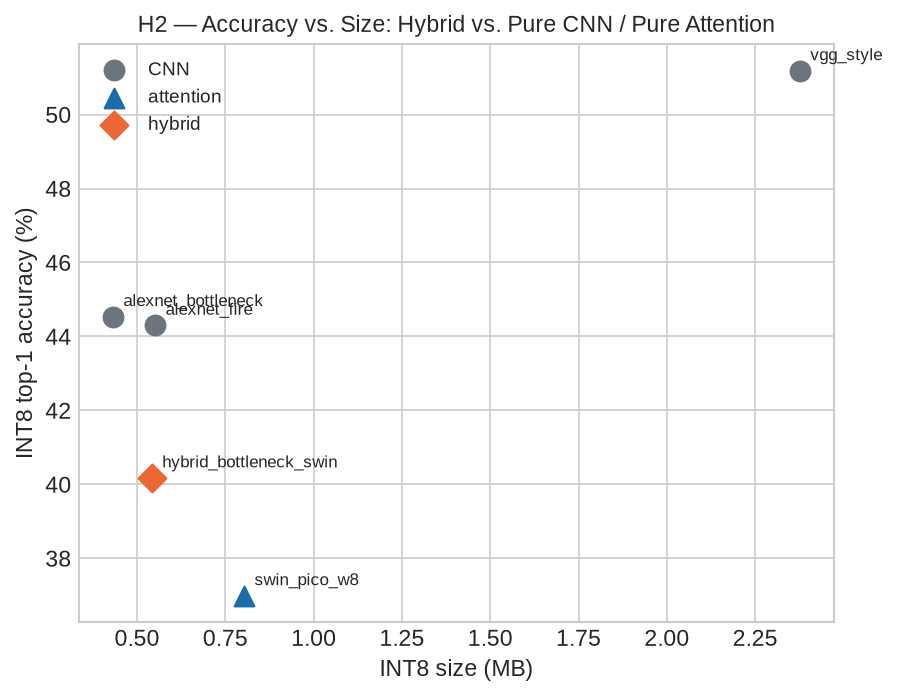

In [6]:
h2_rows = []
for name in ["alexnet_bottleneck", "alexnet_fire", "vgg_style"]:
    if name in cnn_df.index:
        h2_rows.append({"model": name, "family": "CNN", "int8_top1": cnn_df.loc[name, "int8_top1"],
                         "int8_size_mb": cnn_df.loc[name, "int8_size_mb"]})
for name in ["swin_pico_w8", "hybrid_bottleneck_swin"]:
    if name in phase8_df.index:
        h2_rows.append({"model": name, "family": "attention" if name != "hybrid_bottleneck_swin" else "hybrid",
                         "int8_top1": phase8_df.loc[name, "int8_top1"],
                         "int8_size_mb": phase8_df.loc[name, "int8_size_mb"]})

if len(h2_rows) < 2:
    print("[skip] Not enough of {alexnet_bottleneck, alexnet_fire, vgg_style, swin_pico_w8, hybrid_bottleneck_swin} present yet.")
else:
    h2_df = pd.DataFrame(h2_rows)
    print(h2_df.to_string(index=False))

    if "hybrid_bottleneck_swin" in h2_df["model"].values and "swin_pico_w8" in h2_df["model"].values:
        hybrid_top1 = h2_df.loc[h2_df["model"] == "hybrid_bottleneck_swin", "int8_top1"].iloc[0]
        pure_swin_top1 = h2_df.loc[h2_df["model"] == "swin_pico_w8", "int8_top1"].iloc[0]
        print(f"\nHybrid vs. pure-Swin (w8): {hybrid_top1:.2f}% vs. {pure_swin_top1:.2f}% "
              f"({'+' if hybrid_top1 >= pure_swin_top1 else ''}{hybrid_top1 - pure_swin_top1:.2f}pp)")

    fig, ax = plt.subplots(figsize=(6.5, 5))
    family_markers = {"CNN": "o", "attention": "^", "hybrid": "D"}
    for family, group in h2_df.groupby("family"):
        color = CNN_COLOR if family == "CNN" else PHASE8_COLORS.get(group["model"].iloc[0], "#333333")
        ax.scatter(group["int8_size_mb"], group["int8_top1"], marker=family_markers[family],
                   s=90, label=family, color=color if family != "CNN" else CNN_COLOR)
    for _, r in h2_df.iterrows():
        ax.annotate(r["model"], (r["int8_size_mb"], r["int8_top1"]), fontsize=8,
                   xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel("INT8 size (MB)")
    ax.set_ylabel("INT8 top-1 accuracy (%)")
    ax.set_title("H2 — Accuracy vs. Size: Hybrid vs. Pure CNN / Pure Attention")
    ax.legend()
    fig.savefig(FIGURES_DIR / "phase8_h2_hybrid_pareto.png")
    plt.show()


## H3 — Quantization Robustness vs. Phase 3's CNN Compensation Models

INT8/FP32 size ratio and quantization top-1 delta, all present Phase 8 models vs.
`alexnet_bottleneck`/`alexnet_fire` (Phase 3's quantization-stable picks per
`ideas/BEST_MODELS.md`). This is model-size ratio, not the weights-only /
optimizer-state-excluded quantity `ideas/PHASE8_PLAN.md` H3 asks for -- see Limitations.

                         family  size_ratio  quant_drop_top1
model                                                       
alexnet_bottleneck          CNN    0.096127         0.083897
alexnet_fire                CNN    0.092058        -0.327522
hybrid_bottleneck_swin  Phase 8    0.172677        -6.539226
swin_pico_poolmixer     Phase 8    0.114409        -2.548075
swin_pico_w2            Phase 8    0.178045        -2.611920
swin_pico_w4            Phase 8    0.179869        -2.616999
swin_pico_w8            Phase 8    0.205417        -3.960994


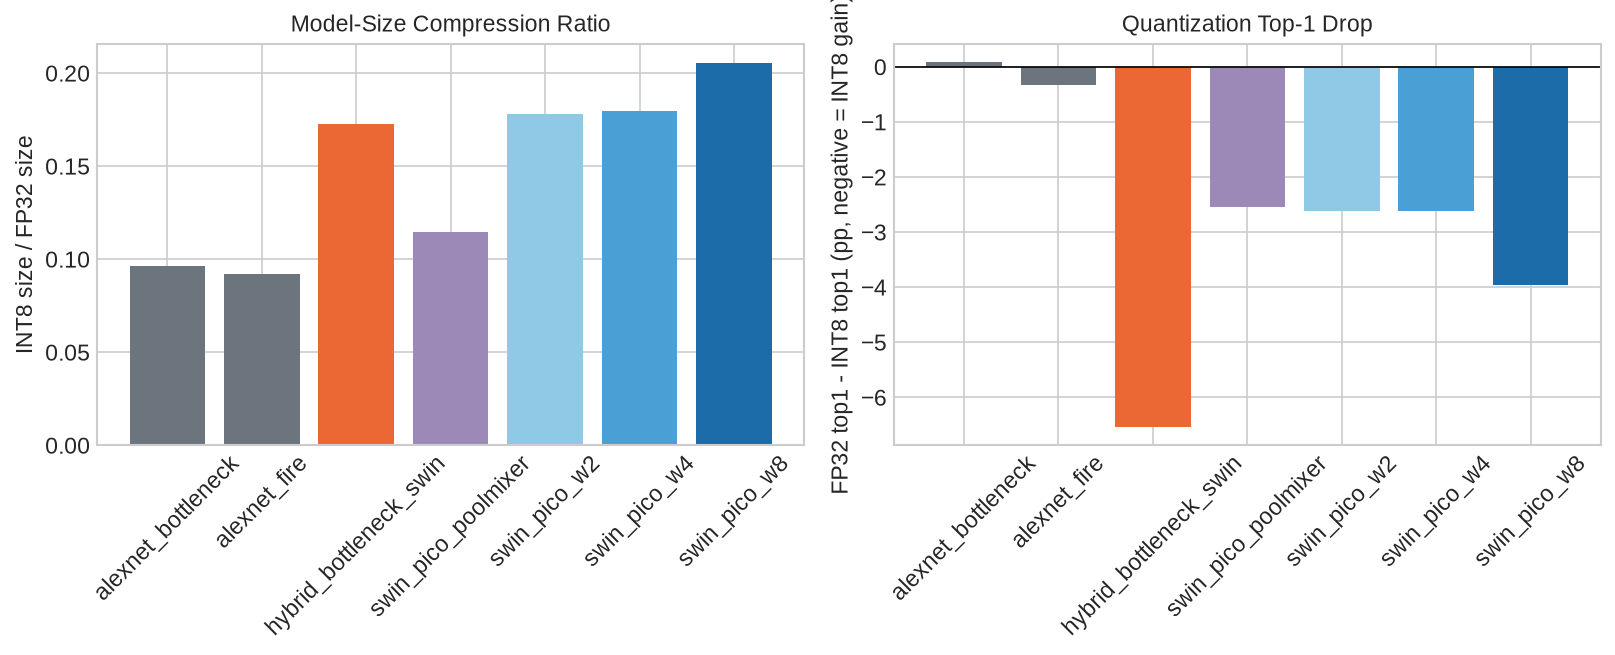

In [7]:
h3_rows = []
for name in cnn_df.index:
    if name in ("alexnet_bottleneck", "alexnet_fire"):
        h3_rows.append({"model": name, "family": "CNN",
                         "size_ratio": cnn_df.loc[name, "int8_size_mb"] / cnn_df.loc[name, "fp32_size_mb"],
                         "quant_drop_top1": cnn_df.loc[name, "quantization_drop_top1"]})
for name in phase8_df.index:
    if pd.notna(phase8_df.loc[name].get("fp32_size_mb")) and pd.notna(phase8_df.loc[name].get("int8_size_mb")):
        h3_rows.append({"model": name, "family": "Phase 8",
                         "size_ratio": phase8_df.loc[name, "int8_size_mb"] / phase8_df.loc[name, "fp32_size_mb"],
                         "quant_drop_top1": phase8_df.loc[name].get("quantization_drop_top1")})

if len(h3_rows) < 2:
    print("[skip] Not enough models with both FP32 and INT8 size on disk yet.")
else:
    h3_df = pd.DataFrame(h3_rows).set_index("model")
    print(h3_df.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    colors = [CNN_COLOR if f == "CNN" else PHASE8_COLORS.get(m, "#333333") for m, f in zip(h3_df.index, h3_df["family"])]
    axes[0].bar(h3_df.index, h3_df["size_ratio"], color=colors)
    axes[0].set_ylabel("INT8 size / FP32 size")
    axes[0].set_title("Model-Size Compression Ratio")
    axes[0].tick_params(axis="x", rotation=45)
    axes[1].bar(h3_df.index, h3_df["quant_drop_top1"], color=colors)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("FP32 top1 - INT8 top1 (pp, negative = INT8 gain)")
    axes[1].set_title("Quantization Top-1 Drop")
    axes[1].tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase8_h3_quantization_robustness.png")
    plt.show()


## H4 — Does Distillation Help? `vit_tiny` vs. `deit_tiny`

Same architecture and hyperparameters (`deit_tiny = vit_tiny` in `models/vit_variants.py`);
only the training loop differs (`DistillationTrainer`, hard-label distillation from a frozen
`mobilenetv2` teacher, Touvron et al. 2021). **Blocked until both are trained** — see the
validity banner.

In [8]:
h4_models = [m for m in ("vit_tiny", "deit_tiny") if m in phase8_df.index]

if len(h4_models) < 2:
    print(f"[blocked] Need both vit_tiny and deit_tiny; have {h4_models}. "
          "Run notebooks/phase_8_efficient_vit/vit_qat_phase8.ipynb "
          "then re-run this cell.")
else:
    h4_df = phase8_df.loc[["vit_tiny", "deit_tiny"], ["fp32_top1", "int8_top1"]]
    print(h4_df.to_string())
    delta = h4_df.loc["deit_tiny", "fp32_top1"] - h4_df.loc["vit_tiny", "fp32_top1"]
    print(f"\nDistillation effect (FP32 top1, deit - vit): {delta:+.2f}pp")

    fig, ax = plt.subplots(figsize=(5, 4.5))
    x = np.arange(2)
    width = 0.35
    ax.bar(x - width / 2, h4_df["fp32_top1"], width, label="FP32", color="#1b6ca8")
    ax.bar(x + width / 2, h4_df["int8_top1"], width, label="INT8", color="#eb6834")
    ax.set_xticks(x)
    ax.set_xticklabels(["vit_tiny\n(undistilled)", "deit_tiny\n(mobilenetv2 teacher)"])
    ax.set_ylabel("Top-1 accuracy (%)")
    ax.set_title("H4 — Distillation Effect")
    ax.legend()
    fig.savefig(FIGURES_DIR / "phase8_h4_distillation.png")
    plt.show()


[blocked] Need both vit_tiny and deit_tiny; have []. Run notebooks/phase_8_efficient_vit/vit_qat_phase8.ipynb then re-run this cell.


## H5 — Winograd Eligibility: Does Attention Dilute Dense-Kernel Structure?

**Claim**: attention-heavy models spend less device time in Winograd-eligible convolution
than a comparable-depth pure-CNN model. Live-profiled on whichever device is available
locally (GPU preferred; `ideas/PHASE8_PLAN.md`'s "full PCAD sweep is a stretch goal" applies
here the same way it did for Phase 6/7). Model constructors are imported directly (not
loaded from checkpoint) since H5 only needs architecture, not trained weights.

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Profiling device: {device}")
if device.type != "cuda":
    print("NOTE: no CUDA device available -- Winograd kernel selection is a cuDNN/GPU "
          "concept, so op-timing/kernel-name results on CPU are not meaningful for this "
          "hypothesis. Latency numbers below are still valid as a CPU reference point.")


Profiling device: cuda


In [10]:
from ml.profiling import profile_model_latency, profile_kernel_trace
from models.vit_variants import vit_tiny, swin_pico_w2, swin_pico_w4, swin_pico_w8, swin_pico_poolmixer, hybrid_bottleneck_swin

H5_CONSTRUCTORS = {
    "swin_pico_w2": swin_pico_w2, "swin_pico_w4": swin_pico_w4, "swin_pico_w8": swin_pico_w8,
    "swin_pico_poolmixer": swin_pico_poolmixer, "hybrid_bottleneck_swin": hybrid_bottleneck_swin,
    "vit_tiny": vit_tiny, "deit_tiny": vit_tiny,  # deit_tiny shares vit_tiny's constructor
}
IMG_SIZE = 64
INPUT_SIZE = (1, 3, IMG_SIZE, IMG_SIZE)

h5_rows = []
for name, ctor in H5_CONSTRUCTORS.items():
    model = ctor(num_classes=200)
    latency_ms = profile_model_latency(model, INPUT_SIZE, device, warmup=20, iters=100)
    trace = profile_kernel_trace(model, torch.randn(INPUT_SIZE), device)
    h5_rows.append({
        "model": name,
        "latency_ms": latency_ms,
        "winograd_trace_detected": trace["winograd_trace_detected"],
        "top_cuda_kernel": trace["top_cuda_kernel"],
    })
    del model

h5_df = pd.DataFrame(h5_rows).set_index("model")
print(h5_df.to_string())
print("\nCaveat (ml/profiling.py's profile_kernel_trace docstring): cuDNN's Winograd kernel "
      "naming is not stable across versions, so winograd_trace_detected=False is weak "
      "evidence of absence, not proof. Report top_cuda_kernel alongside the flag.")


                        latency_ms  winograd_trace_detected                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 top_cuda_kernel
model                                                                                                                       

Phase 3 CNN reference latency (pre-recorded, Phase 6 hardware -- NOT the same device as the live Phase 8 numbers above unless this notebook is also running on that hardware; compare shapes/trends, not absolute ms):
                    latency_ms
model_name                    
alexnet_bottleneck    0.105113
alexnet_fire          0.150724


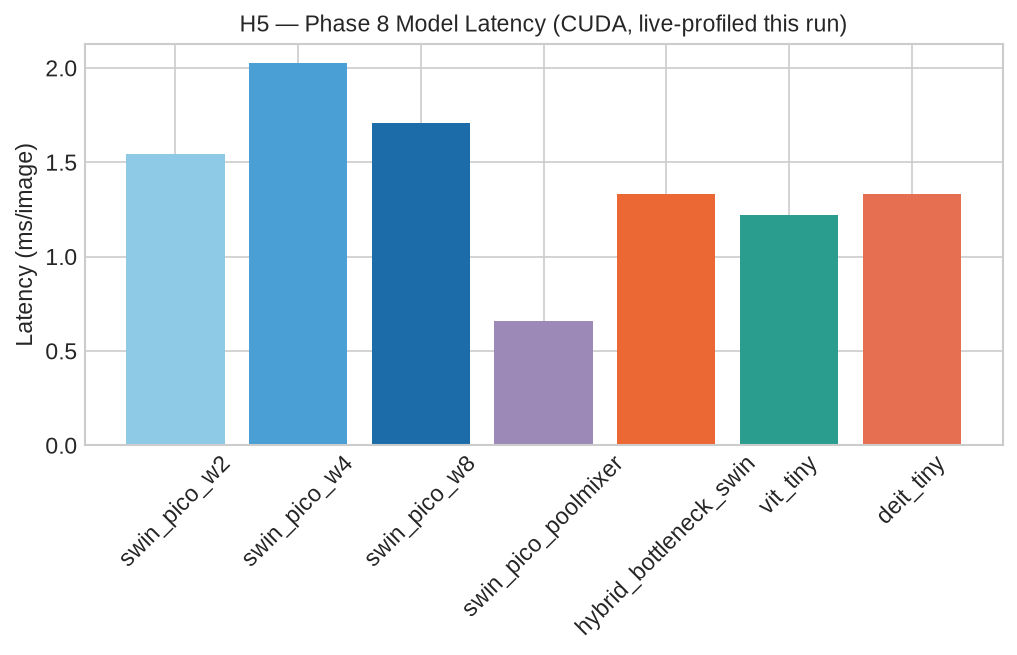

In [11]:
if CROSS_PHASE_CSV.exists() and "alexnet_bottleneck" in cnn_df.index:
    cnn_latency = cnn_df.loc[["alexnet_bottleneck", "alexnet_fire"], ["fp32_latency_ms_per_image"]].rename(
        columns={"fp32_latency_ms_per_image": "latency_ms"})
    print("Phase 3 CNN reference latency (pre-recorded, Phase 6 hardware -- NOT the same "
          "device as the live Phase 8 numbers above unless this notebook is also running on "
          "that hardware; compare shapes/trends, not absolute ms):")
    print(cnn_latency.to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [PHASE8_COLORS.get(m, "#333333") for m in h5_df.index]
ax.bar(h5_df.index, h5_df["latency_ms"], color=colors)
ax.set_ylabel("Latency (ms/image)")
ax.set_title(f"H5 — Phase 8 Model Latency ({device.type.upper()}, live-profiled this run)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase8_h5_latency.png")
plt.show()


## Persist Results

In [12]:
if not phase8_df.empty:
    out_csv = RESULTS_DIR / "phase8_comparison.csv"
    phase8_df.reset_index().to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")
else:
    print("[skip] Nothing to persist -- phase8_df is empty.")


Saved: /home/rafael/Documents/alexnet_rafael/results/phase_8_efficient_vit_hybrid_attention_analysis/phase8_comparison.csv


## Conclusions

*Fill in once all 7 models have results — the cells above already compute every number
needed; this section should summarize, not introduce new analysis.*

- **H1** (window size): _monotonic? which sweep points are present?_
- **H2** (hybrid vs. pure CNN/Swin): _does the CNN-stem hybrid win, and by how much?_
- **H3** (quantization robustness): _do Phase 8 models match Phase 3's Bottleneck/Fire
  quantization-gain property, and at what magnitude?_
- **H4** (distillation): _does deit_tiny beat vit_tiny, and by how much?_
- **H5** (Winograd eligibility): _do attention-heavy models show less Winograd-kernel
  device time than the CNN reference?_

## Limitations

- **2/7 models missing** (`vit_tiny`, `deit_tiny`) as of this writing — H4 and any
  7-model aggregate are provisional until the training notebook completes.
- **H3's size ratio is not weights-only.** `ideas/PHASE8_PLAN.md`'s H3 explicitly warns
  against comparing the CSV's raw `compression_ratio`/size columns across phases without
  excluding optimizer state — this notebook uses on-disk checkpoint size (FP32 vs. INT8),
  which is a reasonable deployment-size proxy but not the same quantity the plan specifies.
- **H5 is whole-model, not per-module.** `profile_kernel_trace()` doesn't yet break down
  device time by submodule (stem vs. attention stage) — that needs new forward-hook
  instrumentation (`ideas/PHASE8_PLAN.md` Blocking Issue #8's original ask), out of scope
  here. The per-op `winograd_trace_detected`/`top_cuda_kernel` signal is whole-forward-pass.
- **H5's CNN reference latency is not from the same run/hardware** as the live Phase 8
  numbers unless this notebook happens to run on Phase 6's exact profiling hardware —
  compare trends, not absolute milliseconds, same caveat Phase 6/7 state explicitly.
- **Small sample sizes** (3-6 points per hypothesis) — correlation statistics have limited
  power here, same caveat every prior phase's analysis notebook states; report raw numbers
  prominently rather than fitting trend lines beyond the line plot in H1.
